In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Load your dataset
dataset_path = '/content/drive/MyDrive/ckextended.csv'  # Update with the correct path
data = pd.read_csv(dataset_path)

# Check the first few rows to inspect the data
print(data.head())

# Clean the dataset by removing rows with empty or invalid pixel data
data = data[data['pixels'].apply(lambda x: len(x.strip()) > 0)]  # Drop rows with empty pixels

# Convert the pixel data from string to a numpy array of integers
X = data['pixels'].apply(lambda x: np.fromstring(x, sep=' ', dtype=int)).values

# Reshape the data into 48x48 images with 1 channel (grayscale)
X = np.array([x.reshape(48, 48, 1) for x in X])

# Normalize the pixel values to [0, 1]
X = X / 255.0

# Check the shape of X to ensure it has been reshaped properly
print(X.shape)  # Should output (num_samples, 48, 48, 1)

# Extract the emotion labels
emotion_labels = data['emotion'].values

# Replace any '7' labels with '6' (if necessary)
emotion_labels = np.where(emotion_labels == 7, 6, emotion_labels)

# One-hot encode the emotion labels
emotion_labels = to_categorical(emotion_labels, num_classes=7)

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, emotion_labels, test_size=0.2, random_state=42)

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')  # 7 classes (0-6)
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')



   emotion                                             pixels     Usage
0        6  36 39 35 25 19 11 8 7 3 13 15 9 21 57 75 90 10...  Training
1        6  88 74 19 4 5 5 3 12 8 21 15 21 15 18 24 29 32 ...  Training
2        6  9 2 4 7 1 1 1 0 7 29 49 76 115 141 156 169 177...  Training
3        6  104 106 108 104 95 50 60 61 58 83 126 133 139 ...  Training
4        6  68 72 67 67 6 2 1 1 1 1 1 14 24 24 38 65 79 94...  Training
(920, 48, 48, 1)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.5642 - loss: 1.4545 - val_accuracy: 0.6630 - val_loss: 1.2513
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.6573 - loss: 1.3433 - val_accuracy: 0.6630 - val_loss: 1.2864
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.6790 - loss: 1.2191 - val_accuracy: 0.6630 - val_loss: 1.1385
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.6847 - loss: 1.0919 - val_accuracy: 0.6685 - val_loss: 1.0070
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.6731 - loss: 1.0409 - val_accuracy: 0.7391 - val_loss: 0.7432
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.7217 - loss: 0.9008 - val_accuracy: 0.8207 - val_loss: 0.6578
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.7743 - loss: 0.7105 - val_accuracy: 0.8424 - val_loss: 0.5620
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.8089 - loss: 0.6489 - val_accuracy: 0.8587 -

In [ ]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


6/6 - 0s - 75ms/step - accuracy: 0.8641 - loss: 0.4491
Test Accuracy: 86.41%


In [ ]:
import pandas as pd

# Load your dataset (replace 'your_dataset.csv' with your actual file path)
data = pd.read_csv('/content/drive/MyDrive/ckextended.csv')

# Print the size of the dataset
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("Total number of elements:", data.size)



Number of rows: 920
Number of columns: 3
Total number of elements: 2760


In [ ]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Compare predictions to true labels
for i in range(5):  # Display first 5 examples
    print(f"True: {true_classes[i]}, Predicted: {predicted_classes[i]}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step
True: 6, Predicted: 6
True: 6, Predicted: 6
True: 6, Predicted: 6
True: 6, Predicted: 6
True: 6, Predicted: 6


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(true_classes, predicted_classes))
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes))


Confusion Matrix:
[[  4   0   0   0   0   0   5   0]
 [  1   8   0   0   0   0   4   0]
 [  0   0   0   0   0   0   5   0]
 [  0   0   0  11   0   0   0   0]
 [  1   0   0   0   0   0   5   0]
 [  0   0   0   0   0  18   0   0]
 [  0   0   0   0   0   0 118   0]
 [  0   0   0   0   0   1   3   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.44      0.53         9
           1       1.00      0.62      0.76        13
           2       0.00      0.00      0.00         5
           3       1.00      1.00      1.00        11
           4       0.00      0.00      0.00         6
           5       0.95      1.00      0.97        18
           6       0.84      1.00      0.91       118
           7       0.00      0.00      0.00         4

    accuracy                           0.86       184
   macro avg       0.56      0.51      0.52       184
weighted avg       0.80      0.86      0.82       184



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
!pip install pgmpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.8 MB/s eta 0:00:00


In [ ]:
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Define the structure of the BN: a simple chain structure for illustration
model = BayesianNetwork([('Happy', 'Sad'), ('Sad', 'Anger')])

# Define the conditional probability distributions (CPDs) for each node
cpd_happy = TabularCPD(variable='Happy', variable_card=2, values=[[0.7], [0.3]])  # P(Happy)
# P(Sad | Happy): For Sad=0 and Sad=1, we define probabilities for both Happy=0 and Happy=1
cpd_sad = TabularCPD(variable='Sad', variable_card=2,
                     values=[[0.6, 0.4],   # P(Sad=0 | Happy=0) and P(Sad=0 | Happy=1)
                             [0.4, 0.6]],  # P(Sad=1 | Happy=0) and P(Sad=1 | Happy=1)
                     evidence=['Happy'], evidence_card=[2])  # Evidence is 'Happy' with 2 states
cpd_anger = TabularCPD(variable='Anger', variable_card=2,
                       values=[[0.5, 0.5],   # P(Anger=0 | Sad=0) and P(Anger=0 | Sad=1)
                               [0.5, 0.5]],  # P(Anger=1 | Sad=0) and P(Anger=1 | Sad=1)
                       evidence=['Sad'], evidence_card=[2])  # Evidence is 'Sad' with 2 states

# Add the CPDs to the model
model.add_cpds(cpd_happy, cpd_sad, cpd_anger)

# Check if the model is valid
model.check_model()

# Perform inference
inference = VariableElimination(model)
predicted_anger = inference.query(variables=['Anger'], evidence={'Sad': 1})
print(predicted_anger)


+----------+--------------+
| Anger    |   phi(Anger) |
+==========+==============+
| Anger(0) |       0.5000 |
+----------+--------------+
| Anger(1) |       0.5000 |
+----------+--------------+


In [ ]:
!pip install fairlearn
!pip install raiwidgets # Install raiwidgets, if you are going to use the Fairlearn dashboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.3/232.3 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.5/177.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.9/157.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.5/41.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 M

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import imgaug.augmenters as iaa
from sklearn.metrics import classification_report, accuracy_score
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import selection_rate  # For additional fairness metrics
from raiwidgets import FairnessDashboard
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Load the dataset
data_path = '/content/drive/MyDrive/ckextended.csv'
data = pd.read_csv(data_path)

# Convert 'pixels' column from strings to numpy arrays
data['pixels'] = data['pixels'].apply(lambda x: np.fromstring(x, sep=' '))

# Reshape and normalize the pixel values
X = np.array([x.reshape(48, 48, 1) for x in data['pixels'].values])
X = X / 255.0  # Normalize pixel values

# Get the number of classes based on unique labels
y = data['emotion'].values
num_classes = len(np.unique(y))  # Automatically sets the correct number of classes

# One-hot encode the labels
y = to_categorical(y, num_classes=num_classes)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define augmentation using imgaug
augmenter = iaa.Sequential([
    iaa.Rotate((-20, 20)),            # Rotate between -20 and +20 degrees
    iaa.Fliplr(0.5),                  # Horizontal flip 50% of the time
    iaa.GaussianBlur(sigma=(0.0, 1.0)), # Apply Gaussian blur with random sigma
    iaa.Affine(scale=(0.8, 1.2)),     # Randomly zoom in/out
])

# Apply augmentation to training data
def augment_images(images):
    images_augmented = augmenter(images=images)
    return np.array(images_augmented)

# Augment X_train and double the training data size
X_train_augmented = augment_images(X_train)
X_train = np.concatenate((X_train, X_train_augmented), axis=0)
y_train = np.concatenate((y_train, y_train), axis=0)

# Define a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile and train the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculate classification metrics for each emotion class
print("Classification report:\n", classification_report(y_true_classes, y_pred_classes))

# Fairness Analysis using Fairlearn
# Treat each emotion class as a separate group for fairness assessment
sensitive_attribute = y_true_classes  # Emotion classes as sensitive attribute

# Create a MetricFrame with accuracy and selection rate metrics
metrics = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate
}
metric_frame = MetricFrame(metrics=metrics,
                           y_true=y_true_classes,
                           y_pred=y_pred_classes,
                           sensitive_features=sensitive_attribute)

# Display fairness metrics by emotion class
print("\nFairness Metrics by Emotion Class:")
print(metric_frame.by_group)

# Optional: Visualize fairness metrics using FairnessDashboard
FairnessDashboard(sensitive_features=sensitive_attribute,
                  y_true=y_true_classes,
                  y_pred={"pred": y_pred_classes})


Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.6124 - loss: 1.4824 - val_accuracy: 0.6413 - val_loss: 1.3211
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.6374 - loss: 1.3924 - val_accuracy: 0.6413 - val_loss: 1.1873
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.6592 - loss: 1.2227 - val_accuracy: 0.7120 - val_loss: 0.9490
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.6924 - loss: 1.0518 - val_accuracy: 0.7935 - val_loss: 0.7811
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.7623 - loss: 0.9080 - val_accuracy: 0.8207 - val_loss: 0.6372
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7756 - loss: 0.7992 - val_accuracy: 0.8370 - val_loss: 0.5620
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.7819 - loss: 0.6978 - val_accuracy: 0.8478 - val_loss: 0.5092
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8134 - loss: 0.6336 - val_accuracy: 0.8478 

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Fairness started at http://localhost:8704


<Figure size 800x600 with 0 Axes>

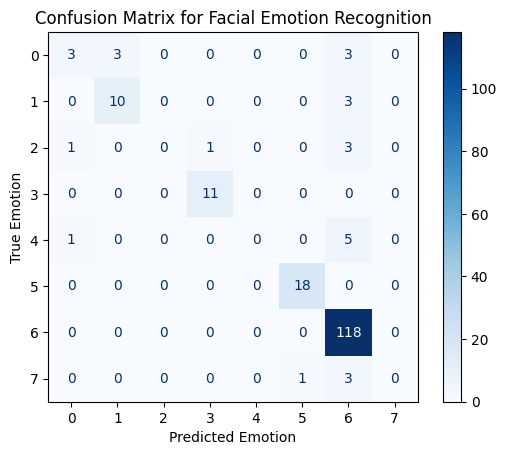

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Assume y_true_classes and y_pred_classes are your true and predicted labels from the video emotion recognition model
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(conf_matrix).plot(cmap='Blues')
plt.title("Confusion Matrix for Facial Emotion Recognition")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()


In [ ]:
!pip install pgmpy

from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Define the structure of the Bayesian Network
# For example, transition probabilities from one emotion to another
emotion_network = BayesianNetwork([('Previous_Emotion', 'Current_Emotion')])

# Define Conditional Probability Distributions (CPDs)
cpd_prev_emotion = TabularCPD(variable='Previous_Emotion', variable_card=3, values=[[0.4], [0.3], [0.3]])
cpd_current_emotion = TabularCPD(variable='Current_Emotion', variable_card=3,
                                 values=[[0.6, 0.3, 0.1],
                                         [0.2, 0.5, 0.3],
                                         [0.2, 0.2, 0.6]],
                                 evidence=['Previous_Emotion'], evidence_card=[3])

# Add CPDs to the network
emotion_network.add_cpds(cpd_prev_emotion, cpd_current_emotion)

# Verify the model structure
emotion_network.check_model()

# Perform inference on the network
inference = VariableElimination(emotion_network)
prob_emotion = inference.query(variables=['Current_Emotion'], evidence={'Previous_Emotion': 1})
print(prob_emotion)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.8 MB/s eta 0:00:00
+--------------------+------------------------+
| Current_Emotion    |   phi(Current_Emotion) |
+====================+========================+
| Current_Emotion(0) |                 0.3000 |
+--------------------+------------------------+
| Current_Emotion(1) |                 0.5000 |
+--------------------+------------------------+
| Current_Emotion(2) |                 0.2000 |
+--------------------+------------------------+


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.metrics import MetricFrame, selection_rate, accuracy_score_group_min

# Generating example dataset for demonstration
# Replace this with your actual dataset
np.random.seed(42)
X = np.random.rand(200, 3)  # 200 samples, 3 feature columns
y = np.random.randint(0, 8, 200)  # 8 classes representing emotions

# **Convert y to binary for DemographicParity (replace with your specific logic)**
# Example: Assuming emotion 0 is the 'positive' class for DemographicParity
y_binary = (y == 0).astype(int)

# Splitting the data using the binary y for mitigation
X_train, X_test, y_train_binary, y_test_binary = train_test_split(X, y_binary, test_size=0.2, random_state=42)
# Splitting the original y for evaluation
_, _, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model = LogisticRegression(max_iter=1000, multi_class='ovr')

# Applying fairness mitigation using ExponentiatedGradient for Demographic Parity
mitigator = ExponentiatedGradient(
    estimator=model,
    constraints=DemographicParity()
)

# Fit the mitigated model with sensitive feature as the target emotion classes
# (y_train_binary here is used as a proxy for sensitive groups)
mitigator.fit(X_train, y_train_binary, sensitive_features=y_train)

# Predict on the test set
y_pred_mitigated = mitigator.predict(X_test)

# Display classification report after mitigation
print("Classification Report After Mitigation:")
print(classification_report(y_test_binary, y_pred_mitigated))

# Calculate and display accuracy after mitigation
accuracy_mitigated = accuracy_score(y_test_binary, y_pred_mitigated)
print(f"Overall Accuracy After Mitigation: {accuracy_mitigated:.2f}")

# Fairness metrics by emotion class after mitigation
metric_frame_mitigated = MetricFrame(
    metrics={"accuracy": accuracy_score, "selection_rate": selection_rate},
    y_true=y_test_binary,
    y_pred=y_pred_mitigated,
    sensitive_features=y_test
)

# Print the fairness metrics for each emotion class after mitigation
print("Fairness Metrics by Emotion Class After Mitigation:")
print(metric_frame_mitigated.by_group)
print(f"Group Minimum Accuracy After Mitigation: {accuracy_score_group_min(y_test_binary, y_pred_mitigated, sensitive_features=y_test):.2f}")

/usr/local/lib/python3.10/dist-packages/fairlearn/reductions/_moments/utility_parity.py:251: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  lambda_event = (lambda_vec["+"] - self.ratio * lambda_vec["-"]).sum(level=_EVENT) / \
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/fairlearn/reductions/_moments/utility_parity.py:251: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  lambda_event = (la

Classification Report After Mitigation:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        34
           1       0.00      0.00      0.00         6

    accuracy                           0.85        40
   macro avg       0.42      0.50      0.46        40
weighted avg       0.72      0.85      0.78        40

Overall Accuracy After Mitigation: 0.85
Fairness Metrics by Emotion Class After Mitigation:
                    accuracy selection_rate
sensitive_feature_0                        
0                        0.0            0.0
1                        1.0            0.0
2                        1.0            0.0
3                        1.0            0.0
4                        1.0            0.0
5                        1.0            0.0
6                        1.0            0.0
7                        1.0            0.0
Group Minimum Accuracy After Mitigation: 0.00


/usr/local/lib/python3.10/dist-packages/fairlearn/reductions/_moments/utility_parity.py:251: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  lambda_event = (lambda_vec["+"] - self.ratio * lambda_vec["-"]).sum(level=_EVENT) / \
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/fairlearn/reductions/_moments/utility_parity.py:251: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  lambda_event = (la